UCI Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      124             91             98      552  34.7   
1           14      195            111             19      317  38.0   
2           10      125            118             60      501  20.9   
3            7       58             89             34      827  42.2   
4            6      123             72             49      380  22.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     1.370   76        0  
1                     1.270   50        1  
2                     0.308   77        1  
3                     1.659   50        1  
4                     2.064   67        1  

Pima Indians Diabetes Dataset Sample:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0           16      103             44             87      659  43.5   
1           10      164            100             39      320  37.1   
2            2     

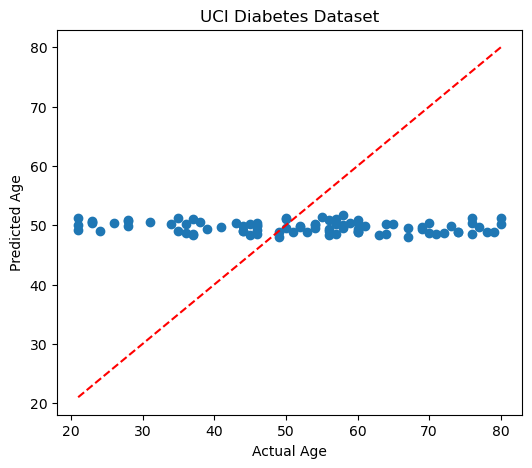

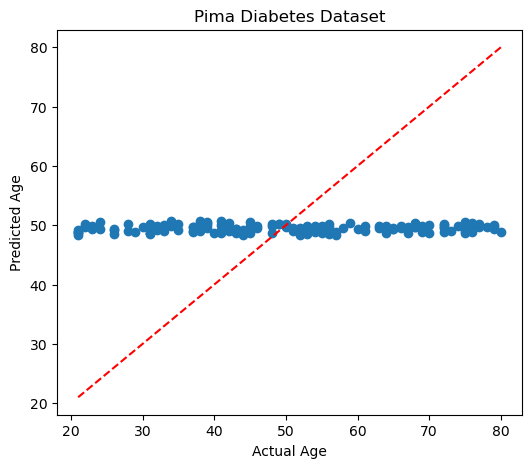

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load the Datasets
uci_diabetes = pd.read_csv("uci_diabetes.csv")
pima_diabetes = pd.read_csv("pima_diabetes.csv")

# Display Sample Data
print("UCI Diabetes Dataset Sample:")
print(uci_diabetes.head())

print("\nPima Indians Diabetes Dataset Sample:")
print(pima_diabetes.head())

# Select Features and Target Variable
features = ["Glucose", "BloodPressure", "BMI"]
target = "Age"

# Prepare Data
X_uci = uci_diabetes[features]
y_uci = uci_diabetes[target]

X_pima = pima_diabetes[features]
y_pima = pima_diabetes[target]

# Split Data into Training and Testing Sets (80%-20%)
X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci,
    y_uci,
    test_size=0.20,
    random_state=42
)

X_train_pima, X_test_pima, y_train_pima, y_test_pima = train_test_split(
    X_pima,
    y_pima,
    test_size=0.20,
    random_state=42
)

# Train the Linear Regression Model
model_uci = LinearRegression()
model_uci.fit(X_train_uci, y_train_uci)

model_pima = LinearRegression()
model_pima.fit(X_train_pima, y_train_pima)

# Make Predictions
y_pred_uci = model_uci.predict(X_test_uci)
y_pred_pima = model_pima.predict(X_test_pima)

# Evaluate Model Performance
r2_uci = r2_score(y_test_uci, y_pred_uci)
mse_uci = mean_squared_error(y_test_uci, y_pred_uci)
mae_uci = mean_absolute_error(y_test_uci, y_pred_uci)

r2_pima = r2_score(y_test_pima, y_pred_pima)
mse_pima = mean_squared_error(y_test_pima, y_pred_pima)
mae_pima = mean_absolute_error(y_test_pima, y_pred_pima)

# Display Results
print("\n========================================")
print("UCI Diabetes Dataset - Linear Regression")
print("========================================")
print(f"R² Score : {r2_uci:.4f}")
print(f"MSE      : {mse_uci:.4f}")
print(f"MAE      : {mae_uci:.4f}")

print("\n========================================")
print("Pima Indians Diabetes Dataset - Linear Regression")
print("========================================")
print(f"R² Score : {r2_pima:.4f}")
print(f"MSE      : {mse_pima:.4f}")
print(f"MAE      : {mae_pima:.4f}")

# Plot Actual vs Predicted Values for UCI Dataset
plt.figure(figsize=(6,5))
plt.scatter(y_test_uci, y_pred_uci)
plt.plot(
    [y_test_uci.min(), y_test_uci.max()],
    [y_test_uci.min(), y_test_uci.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("UCI Diabetes Dataset")
plt.show()

# Plot Actual vs Predicted Values for Pima Dataset
plt.figure(figsize=(6,5))
plt.scatter(y_test_pima, y_pred_pima)
plt.plot(
    [y_test_pima.min(), y_test_pima.max()],
    [y_test_pima.min(), y_test_pima.max()],
    'r--'
)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Pima Diabetes Dataset")
plt.show()